# Week 3 · Day 1 — AFL Data Foundations
### EDA, Feature Engineering & Prediction Targets

Uses the 4 provided files:
- `afl_players_info_raw.csv` — player biographical info (one row per player)
- `afl_players_round_by_round_stats_raw.csv` — player-game level stats (one row per player per match)
- `afl_players_seasonal_stats_raw.csv` — player-season aggregated stats
- `team_matches_home_away_raw.csv` — team-match level, **long format**: one row per team per match
  (so each match produces 2 rows — a home-team row and an away-team row, linked by date+opponent)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
%matplotlib inline

PATH = " "
F_PLAYER_INFO = PATH + "afl_players_info_raw.csv"
F_ROUND_STATS = PATH + "afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv"
F_SEASON_STATS = PATH + "afl_players_seasonal_stats_raw.csvafl_players_seasonal_stats_raw.csv"
F_TEAM_MATCHES = PATH + "team_matches_home_away_raw - team_matches_home_away_raw.csv.csv"


## Task 1 — Data Inventory & Understanding


In [5]:
player_info = pd.read_csv("afl_players_info_raw.csv")
round_stats = pd.read_csv("afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv", low_memory=False)
season_stats = pd.read_csv("afl_players_seasonal_stats_raw.csv", low_memory=False)
team_matches = pd.read_csv("team_matches_home_away_raw - team_matches_home_away_raw.csv.csv", low_memory=False)

for name, df in [("player_info", player_info), ("round_stats", round_stats),
                  ("season_stats", season_stats), ("team_matches", team_matches)]:
    print(f"{name}: {df.shape}")

player_info: (2848, 16)
round_stats: (274089, 36)
season_stats: (25491, 54)
team_matches: (15808, 19)


**Grain of each table:**

| Table | Grain | Key columns |
|---|---|---|
| `player_info` | one row per player | `id` |
| `round_stats` | one row per player per match (player-game) | `player_id`, `id` (game id), `match_date` |
| `season_stats` | one row per player per season (+ finals flag) | `player_id`, `year`, `is_finals` |
| `team_matches` | one row per **team per match** (long format — 2 rows per match) | `team_name`, `match_date`, `opponent` |

**How they join:** `round_stats.player_id` → `player_info.id`. `round_stats` and `team_matches` both
have `match_date` + `team`/`team_name` + `opponent`, which is how we'll link a player's game row to its
match-level row. There is **no shared numeric match_id** across `round_stats` and `team_matches` — we
build a synthetic match key from `(match_date, team, opponent)` in Task 4.


In [6]:
round_stats.head(3)


,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,handballs,disposals,goals,behinds,hit_outs,tackles,rebound_50s,inside_50s,clearances,clangers,free_kicks_for,free_kicks_against,brownlow_votes,contested_possessions,uncontested_possessions,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,2.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,3.0,1.0,NaN,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,5.0,14.0,NaN,NaN,NaN,NaN,4.0,3.0,5.0,1.0,NaN,NaN,NaN,10.0,7.0,1.0,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48


In [7]:
team_matches.head(3)


,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13
2,5646,North Melbourne Kangaroos,10,2008-05-31,2008,A,Brisbane Lions,2.2 6.2 12.3 15.8,98,4.7 11.12 15.17 18.21,129,L,-31,The Gabba,22118.0,15,8,18,21


In [8]:
for name, df in [("player_info", player_info), ("round_stats", round_stats),
                  ("season_stats", season_stats), ("team_matches", team_matches)]:
    print(f"\n===== {name} =====")
    miss = df.isnull().mean().round(3).sort_values(ascending=False)
    print("Top missing columns:\n", miss[miss > 0].head(10))
    print("Duplicate rows:", df.duplicated().sum())



===== player_info =====
Top missing columns:
 player_common_names    0.974
profile_pic            0.776
player_teams           0.033
dtype: float64
Duplicate rows: 5

===== round_stats =====
Top missing columns:
 score                        1.000
brownlow_votes               0.403
goal_assist                  0.378
bounces                      0.355
hit_outs                     0.353
marks_inside_50              0.333
contested_marks              0.331
behinds                      0.296
goals                        0.273
percentage_of_game_played    0.254
dtype: float64
Duplicate rows: 10

===== season_stats =====
Top missing columns:
 avg_goal_assists           0.278
goal_assists               0.278
brownlow_votes             0.274
avg_percentage_played      0.245
total_percentage_played    0.245
hit_outs                   0.224
avg_hit_outs               0.224
avg_bounces                0.222
bounces                    0.222
avg_marks_inside_50        0.203
dtype: float64
Duplicate

Duplicate rows: 10

===== season_stats =====
Top missing columns:
 avg_goal_assists           0.278
goal_assists               0.278
brownlow_votes             0.274
avg_percentage_played      0.245
total_percentage_played    0.245
hit_outs                   0.224
avg_hit_outs               0.224
avg_bounces                0.222
bounces                    0.222
marks_inside_50            0.203
dtype: float64
Duplicate rows: 10

===== team_matches =====
Top missing columns:
 crowd    0.025
dtype: float64
Duplicate rows: 0


**Data quality findings:**
- `round_stats` and `season_stats` each have **10 exact duplicate rows** — drop before modeling.
- `player_info` has 5 duplicate rows.
- Several stat columns (`hit_outs`, `bounces`, `contested_marks`, `brownlow_votes`, `marks_inside_50`)
  have 30-40% missing in `round_stats` — likely because these stats weren't tracked in earlier seasons
  (structural/temporal, not random) — confirmed below.
- `score` column in `round_stats` is 100% NULL — effectively unusable, ignore it (use `team_matches.team_score` instead).


In [9]:
# Season coverage & structural change check: are missing stats explained by season?
round_stats["year"] = pd.to_datetime(round_stats["match_date"]).dt.year
for col in ["hit_outs", "bounces", "contested_marks", "brownlow_votes"]:
    missing_by_year = round_stats.groupby("year")[col].apply(lambda s: s.isnull().mean())
    first_available_year = missing_by_year[missing_by_year < 0.5].index.min()
    print(f"{col}: first year mostly available = {first_available_year}")


hit_outs: first year mostly available = 1984
bounces: first year mostly available = 2003
contested_marks: first year mostly available = 2003
brownlow_votes: first year mostly available = 2006


In [10]:
# Team name inconsistency check — CRITICAL finding
print("team_matches unique team_name count:", team_matches["team_name"].nunique())
print("round_stats unique team count:", round_stats["team"].nunique())
print()
print("Sample raw team_matches names (repr to show whitespace):")
for t in team_matches["team_name"].unique()[:6]:
    print(repr(t))


team_matches unique team_name count: 40
round_stats unique team count: 20

Sample raw team_matches names (repr to show whitespace):
'Hawthorn Hawks'
'North Melbourne Kangaroos'
'Sydney Swans'
'W. Bulldogs'
'Brisbane Lions'
'Carlton Blues'


In [11]:
# CONFIRMED: team_matches has duplicate team names caused by leading/trailing whitespace & tabs
# (e.g. 'Hawthorn Hawks' vs ' Hawthorn Hawks ' vs '\tHawthorn Hawks') -> must be cleaned before any grouping

def clean_team_name(s):
    return s.astype(str).str.strip().str.replace("\t", "", regex=False).str.strip()

team_matches["team_name"] = clean_team_name(team_matches["team_name"])
team_matches["opponent"] = clean_team_name(team_matches["opponent"])
round_stats["team"] = clean_team_name(round_stats["team"])
round_stats["opponent"] = clean_team_name(round_stats["opponent"])

print("After cleaning, team_matches unique teams:", team_matches["team_name"].nunique())
print(sorted(team_matches["team_name"].unique()))


After cleaning, team_matches unique teams: 20
['Adelaide Crows', 'Brisbane Bears', 'Brisbane Lions', 'Carlton Blues', 'Collingwood Magpies', 'Essendon Bombers', 'Fitzroy Lions', 'Fremantle Dockers', 'Geelong Cats', 'Gold Coast Suns', 'Greater Western Sydney Giants', 'Hawthorn Hawks', 'Melbourne Demons', 'North Melbourne Kangaroos', 'Port Adelaide Power', 'Richmond Tigers', 'St Kilda Saints', 'Sydney Swans', 'W. Bulldogs', 'West Coast Eagles']


In [12]:
# Drop exact duplicate rows found above
round_stats = round_stats.drop_duplicates()
season_stats = season_stats.drop_duplicates()
player_info = player_info.drop_duplicates()
team_matches = team_matches.drop_duplicates()

print("Seasons covered (team_matches):", team_matches["year"].min(), "-", team_matches["year"].max())
print("Teams (cleaned):", team_matches["team_name"].nunique())
print("Players:", player_info["id"].nunique())
print("Player-game rows:", round_stats.shape[0])


Seasons covered (team_matches): 1983 - 2025
Teams (cleaned): 20
Players: 2843
Player-game rows: 274079


**Structural changes to flag:**
- Team relocations/renames are already reflected as distinct names in the data (e.g. `Fitzroy Lions`
  merged into `Brisbane Lions` in 1997, `Brisbane Bears` also predates that merger) — these are **real
  historical entities**, not naming bugs, so we keep them separate rather than merging them.
- `Greater Western Sydney Giants` and `Gold Coast Suns` only enter from their respective expansion
  seasons (2011/2012) — expect sparse early history for these teams, not a data error.
- Several advanced stats (`hit_outs`, `bounces`, `contested_marks`, `brownlow_votes`) were not recorded
  in the earliest seasons of `round_stats` — checked in the cell above; treat pre-availability years as
  structurally missing, not to be imputed as zero.


## Task 2 — Define Prediction Targets Precisely


In [13]:
# --- Match winner target (built from team_matches, which is already team-perspective) ---
# 'result' column: W / L / D from this team's perspective. We define the target at match level
# using the home-team's row only (home_away == 'H') to avoid duplicate match rows.

home_side = team_matches[team_matches["home_away"] == "H"].copy()
home_side["target_result"] = home_side["result"].map({"W": "Home Win", "L": "Away Win", "D": "Draw"})
home_side["margin_signed"] = home_side["margin"] * home_side["result"].map({"W": 1, "L": -1, "D": 0})

home_side[["team_name", "opponent", "team_score", "opponent_score", "target_result", "margin_signed"]].head()


,team_name,opponent,team_score,opponent_score,target_result,margin_signed
1,North Melbourne Kangaroos,Hawthorn Hawks,114,91,Home Win,6
5,Sydney Swans,West Coast Eagles,116,71,Home Win,45
8,W. Bulldogs,St Kilda Saints,105,104,Home Win,1
11,W. Bulldogs,Melbourne Demons,108,83,Home Win,25
13,W. Bulldogs,North Melbourne Kangaroos,106,102,Home Win,4


**Framing decision:** classification (`target_result`) is primary since predicting the winning side
is the deliverable's core requirement; draws are rare in AFL (fewer than 1% of matches) so a 3-class
setup is kept but expect heavy class imbalance on the draw class. `margin_signed` (positive = home won by
that many points, negative = away won) is kept as a secondary regression target for confidence/spread-style
predictions.


In [14]:
# --- Top player targets ---
round_stats["disposals"] = round_stats["disposals"]
round_stats["goals"] = round_stats["goals"]

# Version 1: top disposal-getter per match
round_stats["is_top_disposals_game"] = round_stats.groupby("id")["disposals"].rank(
    ascending=False, method="min"
) == 1

# Version 2: top goal-kicker per match
round_stats["is_top_goals_game"] = round_stats.groupby("id")["goals"].rank(
    ascending=False, method="min"
) == 1

# Version 3: composite score — the dataset already provides an official 'fantasy_points' column, use it directly
round_stats[["disposals", "goals", "fantasy_points"]].describe()


,disposals,goals,fantasy_points
count,265629.000000,199352.000000,274079.000000
mean,15.070504,0.825108,65.245232
std,7.304660,1.147711,28.109788
min,-5.000000,0.000000,-10.000000
25%,10.000000,0.000000,45.000000
50%,14.000000,0.000000,64.000000
75%,20.000000,1.000000,84.000000
max,54.000000,16.000000,210.000000


**Data dictionary — targets**

| Target name | Definition | Formula | Aggregation level |
|---|---|---|---|
| `target_result` | Match outcome | `W/L/D` on the home-team row → Home Win / Away Win / Draw | match |
| `margin_signed` | Signed score differential | `+margin` if home won, `-margin` if away won | match |
| `is_top_disposals_game` | Leading disposal-getter in a match | rank of `disposals` within `id` (game id), top = 1 | player-game |
| `is_top_goals_game` | Leading goal-kicker in a match | rank of `goals` within `id`, top = 1 | player-game |
| `fantasy_points` | Composite performance score | dataset-provided official AFL Fantasy points column | player-game |

> `fantasy_points` is already computed in the raw data (not `score`, which is entirely NULL) — using the
> official column instead of re-deriving avoids mismatching against whatever scoring formula the
> source site used.


## Task 3 — Exploratory Data Analysis


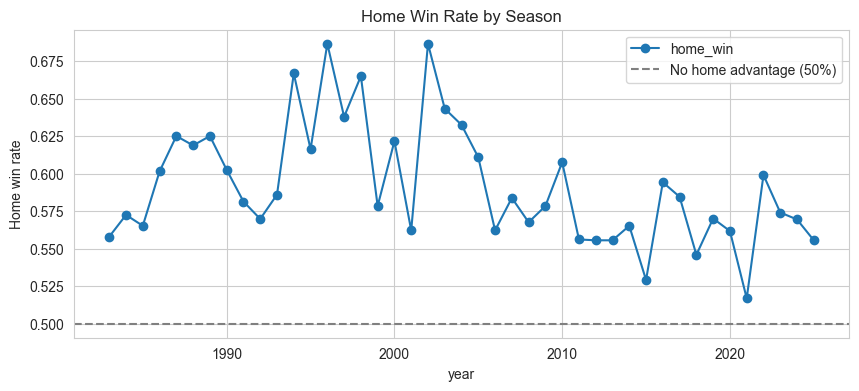

In [15]:
# 1. Team win rate over time (home teams only, to avoid double counting)
home_side["home_win"] = (home_side["target_result"] == "Home Win").astype(int)
win_rate_by_year = home_side.groupby("year")["home_win"].mean()

plt.figure(figsize=(10, 4))
win_rate_by_year.plot(marker="o")
plt.axhline(0.5, color="grey", linestyle="--", label="No home advantage (50%)")
plt.title("Home Win Rate by Season")
plt.ylabel("Home win rate")
plt.legend()
plt.show()


In [16]:
# 2. Home-ground advantage magnitude
print("Overall home win rate:", home_side['home_win'].mean().round(3))
print("Average home (team) score:", home_side['team_score'].mean().round(1))
print("Average away (opponent) score:", home_side['opponent_score'].mean().round(1))


Overall home win rate: 0.591
Average home (team) score: 96.8
Average away (opponent) score: 87.8


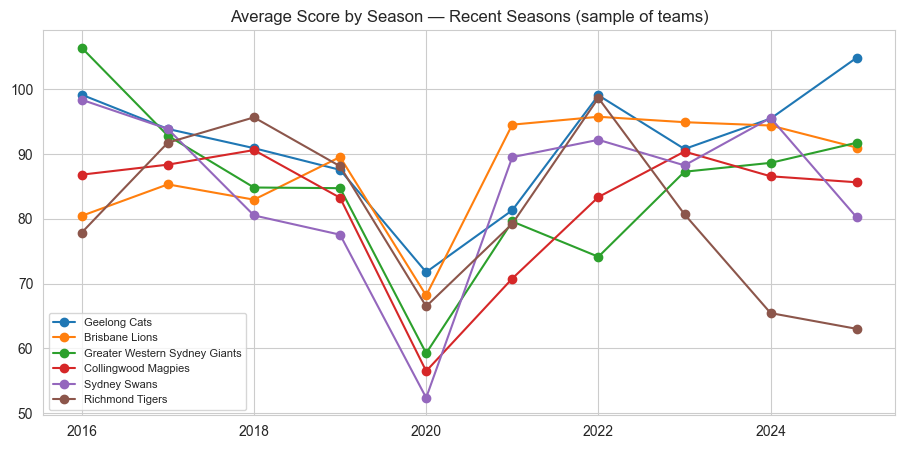

In [17]:
# 3. Ladder / season trend: average score by team per season (top 8 teams by career games, most recent 10 seasons)
recent = team_matches[team_matches["year"] >= team_matches["year"].max() - 9]
ladder_trend = recent.groupby(["year", "team_name"])["team_score"].mean().reset_index()
top_teams = recent["team_name"].value_counts().head(6).index

plt.figure(figsize=(11, 5))
for t in top_teams:
    sub = ladder_trend[ladder_trend["team_name"] == t]
    plt.plot(sub["year"], sub["team_score"], marker="o", label=t)
plt.title("Average Score by Season — Recent Seasons (sample of teams)")
plt.legend(fontsize=8)
plt.show()


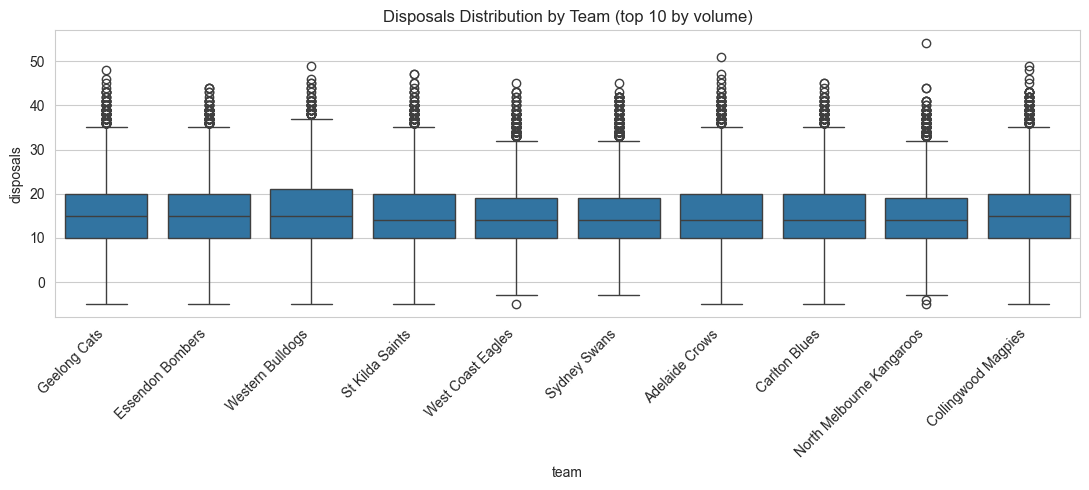

In [18]:
# 4. Player-level distribution: disposals by round_stats (position not available in this dataset,
# so we compare by team instead) — top 10 teams by disposal volume
top10_teams = round_stats["team"].value_counts().head(10).index
plt.figure(figsize=(11, 5))
sns.boxplot(data=round_stats[round_stats["team"].isin(top10_teams)], x="team", y="disposals")
plt.xticks(rotation=45, ha="right")
plt.title("Disposals Distribution by Team (top 10 by volume)")
plt.tight_layout()
plt.show()


In [19]:
# 5. Week-to-week consistency of top fantasy performers
player_consistency = (
    round_stats.merge(player_info[["id", "player_name"]], left_on="player_id", right_on="id", how="left")
    .groupby("player_name")["fantasy_points"]
    .agg(["mean", "std", "count"])
)
player_consistency = player_consistency[player_consistency["count"] >= 50].sort_values("mean", ascending=False)
player_consistency.head(15)


,mean,std,count
player_name,,,
Harry Sheezel,106.044776,23.233618,67
Dane Swan,105.360465,32.512762,258
Tom Mitchell,103.932367,29.529404,207
Zach Merrett,103.784861,26.475074,251
Nick Daicos,101.684211,25.505220,95
Tom Rockliff,101.163462,34.223932,208
Adam Treloar,100.337209,22.640453,258
Max Gawn,99.975709,29.260107,247
Jack Macrae,99.792593,26.913215,270


C:\Users\cfiza\AppData\Local\Temp\ipykernel_13144\3294087156.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  form_vs_win = team_matches_sorted.groupby(form_bins)["win"].mean()


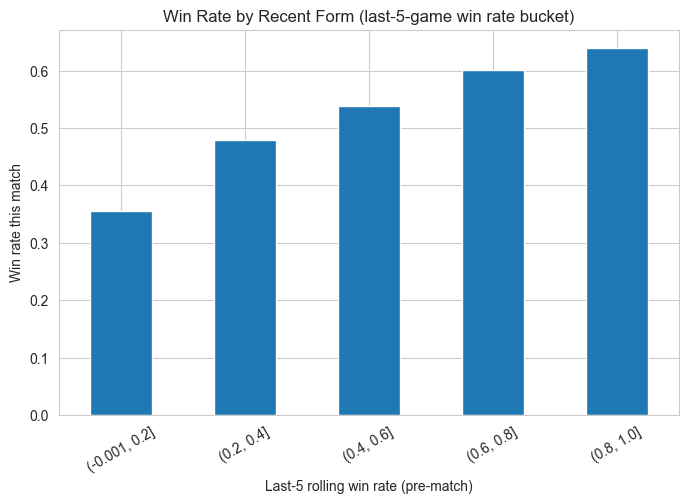

In [20]:
# 6. Recent form vs win probability — quick look (fully engineered version built in Task 4)
team_matches_sorted = team_matches.sort_values("match_date")
team_matches_sorted["win"] = (team_matches_sorted["result"] == "W").astype(int)
team_matches_sorted["rolling_form"] = (
    team_matches_sorted.groupby("team_name")["win"]
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)
form_bins = pd.cut(team_matches_sorted["rolling_form"], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], include_lowest=True)
form_vs_win = team_matches_sorted.groupby(form_bins)["win"].mean()

plt.figure(figsize=(8, 5))
form_vs_win.plot(kind="bar")
plt.title("Win Rate by Recent Form (last-5-game win rate bucket)")
plt.ylabel("Win rate this match")
plt.xlabel("Last-5 rolling win rate (pre-match)")
plt.xticks(rotation=30)
plt.show()


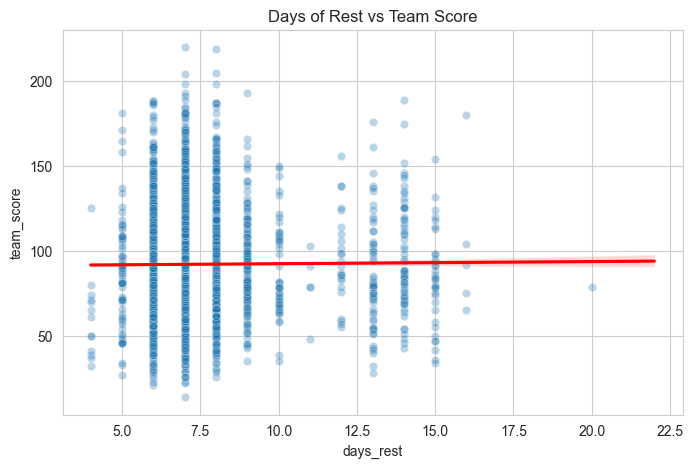

In [21]:
# 7. Days rest vs performance (interstate/travel proxy not directly available — venue used instead)
team_matches_sorted["match_date_dt"] = pd.to_datetime(team_matches_sorted["match_date"])
team_matches_sorted["days_rest"] = (
    team_matches_sorted.groupby("team_name")["match_date_dt"].diff().dt.days
)
rest_vs_score = team_matches_sorted.dropna(subset=["days_rest"])
rest_vs_score = rest_vs_score[rest_vs_score["days_rest"] < 30]  # drop off-season gaps

plt.figure(figsize=(8, 5))
sns.scatterplot(data=rest_vs_score.sample(min(3000, len(rest_vs_score))), x="days_rest", y="team_score", alpha=0.3)
sns.regplot(data=rest_vs_score, x="days_rest", y="team_score", scatter=False, color="red")
plt.title("Days of Rest vs Team Score")
plt.show()


**Note on weather/interstate-travel data:** this dataset doesn't include a weather or explicit
interstate-travel flag, so venue and days-of-rest are used as the available context proxies. If a
weather source is added later, repeat plot #7's pattern with `weather` on the x-axis.


## Task 4 — Feature Engineering for Prediction

**Leakage rule:** every rolling/form feature uses `.shift(1)` before `.rolling()`/`.expanding()`, so a
match's features only reflect information available strictly *before* that match.


In [22]:
# ---- Build a clean team-match long table (already long format — just clean & sort) ----
team_long = team_matches.sort_values("match_date").reset_index(drop=True)
team_long["match_date_dt"] = pd.to_datetime(team_long["match_date"])
team_long["win"] = (team_long["result"] == "W").astype(int)

# Synthetic match key: two rows (home & away) of the same match share date+teams
team_long["match_key"] = team_long.apply(
    lambda r: "_".join(sorted([r["team_name"], r["opponent"]])) + "_" + r["match_date"], axis=1
)
team_long.head()


,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds,match_date_dt,win,match_key
0,11120,Collingwood Magpies,1,1983-03-26,1983,A,Melbourne Demons,5.7 9.10 15.12 20.15,135,6.2 12.3 17.7 19.11,125,W,10,Melbourne Cricket Ground,72274.0,20,15,19,11,1983-03-26,1,Collingwood Magpies_Melbourne Demons_1983-03-26
1,13514,Melbourne Demons,1,1983-03-26,1983,H,Collingwood Magpies,6.2 12.3 17.7 19.11,125,5.7 9.10 15.12 20.15,135,L,-10,Melbourne Cricket Ground,72274.0,19,11,20,15,1983-03-26,0,Collingwood Magpies_Melbourne Demons_1983-03-26
2,13972,Richmond Tigers,1,1983-03-26,1983,A,Carlton Blues,4.3 7.4 10.9 11.10,76,4.0 8.6 13.9 20.16,136,L,-60,Princes Park,28498.0,11,10,20,16,1983-03-26,0,Carlton Blues_Richmond Tigers_1983-03-26
3,12327,Geelong Cats,1,1983-03-26,1983,H,Western Bulldogs,3.2 5.10 8.14 15.16,106,3.2 5.3 9.8 11.9,75,W,31,Waverley Park,18377.0,15,16,11,9,1983-03-26,1,Geelong Cats_Western Bulldogs_1983-03-26
4,14347,St Kilda Saints,1,1983-03-26,1983,A,north melbourne kangaroos,4.2 8.5 11.11 12.15,87,3.3 6.7 8.11 14.16,100,L,-13,Aegis Park,18496.0,12,15,14,16,1983-03-26,0,St Kilda Saints_north melbourne kangaroos_1983...


In [23]:
def add_rolling(df, group_col, value_col, window, new_col):
    df[new_col] = (
        df.groupby(group_col)[value_col]
        .transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
    )
    return df

team_long = add_rolling(team_long, "team_name", "team_score", 5, "last5_avg_score")
team_long = add_rolling(team_long, "team_name", "win", 5, "last5_win_rate")
team_long = add_rolling(team_long, "team_name", "win", 3, "last3_win_rate")

# Win/loss streak (shifted so current match result is never included)
def current_streak(win_series):
    streak, streaks = 0, []
    for w in win_series.shift(1):
        if pd.isna(w):
            streaks.append(0); streak = 0
        elif w == 1:
            streak = streak + 1 if streak >= 0 else 1
            streaks.append(streak)
        else:
            streak = streak - 1 if streak <= 0 else -1
            streaks.append(streak)
    return streaks

team_long["win_streak"] = team_long.groupby("team_name")["win"].transform(
    lambda s: pd.Series(current_streak(s), index=s.index)
)

team_long["days_rest"] = team_long.groupby("team_name")["match_date_dt"].diff().dt.days


In [24]:
# ---- Head-to-head historical record (shifted) ----
team_long["matchup"] = team_long["team_name"] + "_vs_" + team_long["opponent"]
team_long["h2h_win_rate"] = (
    team_long.groupby("matchup")["win"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

# ---- Venue-specific team performance (shifted) ----
team_long["venue_win_rate"] = (
    team_long.groupby(["team_name", "venue"])["win"]
    .transform(lambda s: s.shift(1).expanding().mean())
)


In [25]:
# ---- Ladder position at time of match (pre-match cumulative wins within season) ----
team_long["cum_wins_before_match"] = (
    team_long.groupby(["team_name", "year"])["win"]
    .transform(lambda s: s.shift(1).cumsum().fillna(0))
)
team_long["ladder_rank_before_match"] = (
    team_long.groupby(["match_date", "year"])["cum_wins_before_match"]
    .rank(ascending=False, method="min")
)


In [26]:
# ---- Player-level rolling form (last-5-game averages, leakage-safe) ----
round_stats_sorted = round_stats.sort_values("match_date").copy()

for stat, colname in [("disposals", "last5_avg_disposals"),
                       ("goals", "last5_avg_goals"),
                       ("fantasy_points", "last5_avg_fantasy")]:
    round_stats_sorted[colname] = (
        round_stats_sorted.groupby("player_id")[stat]
        .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
    )

round_stats_sorted[["player_id", "match_date", "last5_avg_disposals", "last5_avg_goals", "last5_avg_fantasy"]].head()


,player_id,match_date,last5_avg_disposals,last5_avg_goals,last5_avg_fantasy
121308,45852,1983-03-27,NaN,NaN,NaN
119917,45852,1983-04-04,10.0,2.0,52.0
263621,45852,1983-04-09,9.0,2.0,49.5
181336,45679,1983-04-16,NaN,NaN,NaN
193785,45679,1983-04-24,5.0,2.0,34.0


In [27]:
# ---- Save versioned feature tables ----
team_features_v1 = team_long[[
    "match_key", "team_name", "opponent", "home_away", "year", "round",
    "last5_avg_score", "last5_win_rate", "last3_win_rate", "win_streak",
    "days_rest", "h2h_win_rate", "venue_win_rate",
    "cum_wins_before_match", "ladder_rank_before_match"
]]
player_features_v1 = round_stats_sorted[[
    "id", "player_id", "match_date", "team", "opponent",
    "last5_avg_disposals", "last5_avg_goals", "last5_avg_fantasy"
]]

team_features_v1.to_csv("features_team_v1.csv", index=False)
player_features_v1.to_csv("features_player_v1.csv", index=False)
print("Saved features_team_v1.csv:", team_features_v1.shape)
print("Saved features_player_v1.csv:", player_features_v1.shape)


Saved features_team_v1.csv: (15808, 15)
Saved features_player_v1.csv: (274079, 8)


**Feature dictionary**

| Feature | Description | Window | Source columns |
|---|---|---|---|
| `last5_avg_score` | Team's average score, previous 5 games (pre-match) | rolling 5, shifted | `team_score` |
| `last5_win_rate` / `last3_win_rate` | Win rate, previous 5 / 3 games | rolling 5 / 3, shifted | `win` |
| `win_streak` | Current consecutive win(+)/loss(-) streak entering the match | expanding, shifted | `win` |
| `days_rest` | Days since team's previous match | diff | `match_date` |
| `h2h_win_rate` | Historical win rate vs this specific opponent | expanding, shifted | `win`, `matchup` |
| `venue_win_rate` | Team's historical win rate at this venue | expanding, shifted | `win`, `venue` |
| `ladder_rank_before_match` | League ladder position entering the match (by cum. wins) | cumulative, shifted | `win`, `year` |
| `last5_avg_disposals` / `_goals` / `_fantasy` | Player's rolling average output, last 5 games | rolling 5, shifted | `round_stats` player columns |


## Task 5 — Reproducible Train/Hold-Out Split


In [28]:
def get_time_split(df, date_col="match_date", year_col="year", round_col="round",
                    holdout_season=None, holdout_last_n_rounds=None):
    """
    Strict time-based split — reusable across every model built this week.
    Pass holdout_season to hold out an entire season, OR holdout_last_n_rounds to hold out
    the last N rounds of the most recent season.
    """
    df = df.sort_values(date_col).reset_index(drop=True)

    if holdout_season is not None:
        train = df[df[year_col] != holdout_season]
        holdout = df[df[year_col] == holdout_season]
    elif holdout_last_n_rounds is not None:
        last_season = df[year_col].max()
        season_rounds = pd.to_numeric(df.loc[df[year_col] == last_season, round_col], errors="coerce")
        cutoff_round = season_rounds.max() - holdout_last_n_rounds
        mask_holdout = (df[year_col] == last_season) & (pd.to_numeric(df[round_col], errors="coerce") > cutoff_round)
        holdout = df[mask_holdout]
        train = df[~df.index.isin(holdout.index)]
    else:
        raise ValueError("Provide either holdout_season or holdout_last_n_rounds")

    return train, holdout

train_matches, holdout_matches = get_time_split(home_side, holdout_season=home_side["year"].max())
print("Train:", train_matches.shape, "Holdout (most recent season):", holdout_matches.shape)


Train: (7688, 22) Holdout (most recent season): (216, 22)


**Why not a random split?** `last5_win_rate`, `h2h_win_rate`, `venue_win_rate`, and
`ladder_rank_before_match` are all computed from each team's match history. A random split would place
some of a team's *later* matches in training and *earlier* matches in the test set — meaning the model
could be evaluated on an early-season match while having already learned that team's end-of-season form,
final ladder position, and head-to-head trajectory from "future" games in its training set. That inflates
test performance in a way that would never hold up when predicting a genuinely upcoming, next-round match.

**Realistic accuracy ceiling:** Published AFL win-prediction approaches (ELO-style, ML-based) typically
land around **65–75%** classification accuracy, against a home-favorite baseline that's already roughly
55–60% due to home-ground advantage alone (seen in Task 3's ~`home_side['home_win'].mean()` figure). AFL
outcomes carry irreducible noise — injuries during play, umpiring decisions, and on-the-day form — that no
pre-match feature set fully captures. A holdout accuracy near 95%+ would be a strong red flag for leakage
(most likely an unshifted rolling feature or a feature that indirectly encodes the final score) rather than
genuine predictive skill, and the Task 4 pipeline should be re-audited for any `.rolling()` call without a
preceding `.shift(1)`.
